In [1]:
from iteration import iteration #import the custom code for running iterations
import numpy as np
import matplotlib.pyplot as plt

In [2]:
resolution = 1025 #pixel width and height

In [3]:
def scale(x):
    """ Scales the x or y coordinate to convert pixel indices to the corresponding x or y coordinate on the real or
    imaginary axis.
    
    Parameters
    ----------
    x : int
        the pixel coordinate on the image (range from 0 to resolution-1)
    
    Returns
    -------
    float
        the corresponding x or y coordinate along the real or imaginary axis (in [-2, 2])
    """
    return ((x / (resolution-1)) - 0.5) * 4

In [4]:
def convert_to_pixel(iterations, absolute):
    """ Converts a given number of iterations taken to diverge to a colour
    
    Parameters
    ----------
    iterations : int
        the number of iterations taken for a point to diverge when iterated through the iteration function
    absolute : bool
        True if the colouring is simply all white or all black based on whether it diverges within the number
        maximum number of iterations (256) or not.
        False if the colouring corresponds to the number of iterations, scaled logarithmically for a nice gradient.
    
    Returns
    -------
    list of int (length 3)
        the outputted pixel value
    """
    if absolute:
        return [0, 0, 0] if iterations == 255 else [255, 255, 255]
    else:
        factor = 1 - np.log(iterations + 1) / np.log(256) #linear would be just be (255-iterations) / 255
        return [int(255*factor), 0, int(255*factor)]

In [5]:
bw_image = []
colour_image = []
for y in reversed(range(resolution)): #so the bottom left in the image corresponds to -2, -2
    bw_row = []
    colour_row = []
    for x in range(resolution):
        iterations = iteration(scale(x), scale(y))
        bw = convert_to_pixel(iterations, True)
        bw_row.append(bw)
        colour = convert_to_pixel(iterations, False)
        colour_row.append(colour)
    bw_image.append(bw_row)
    colour_image.append(colour_row)

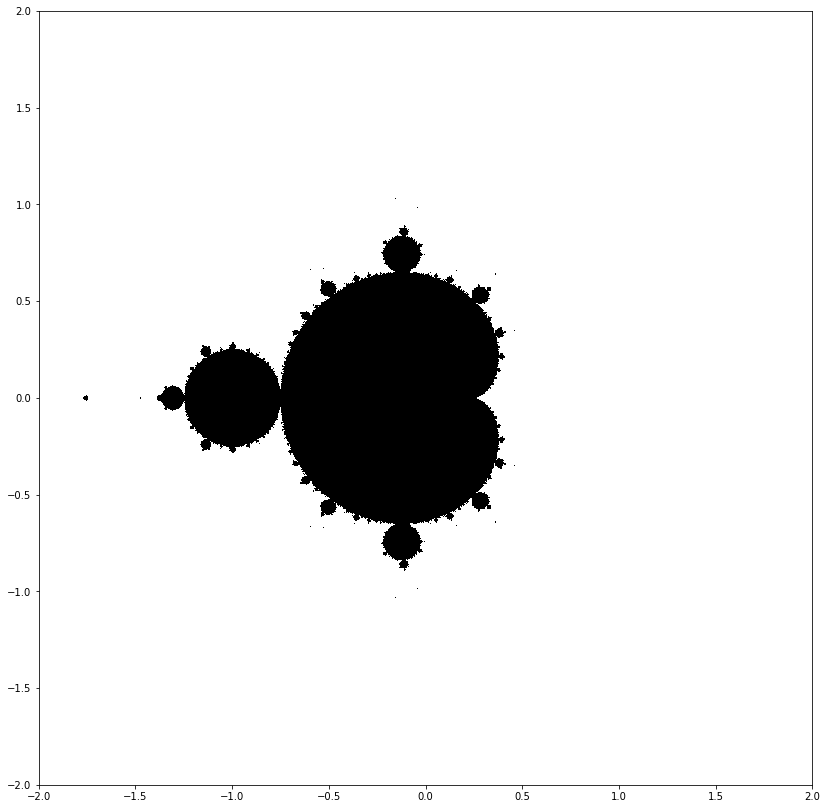

In [8]:
dpi = plt.rcParams['figure.dpi']
figsize = (resolution/dpi, resolution/dpi)

plt.figure(figsize=figsize)
plt.imshow(bw_image, extent=[-2, 2, -2, 2], interpolation="none")
plt.savefig("bw.png")
plt.show()

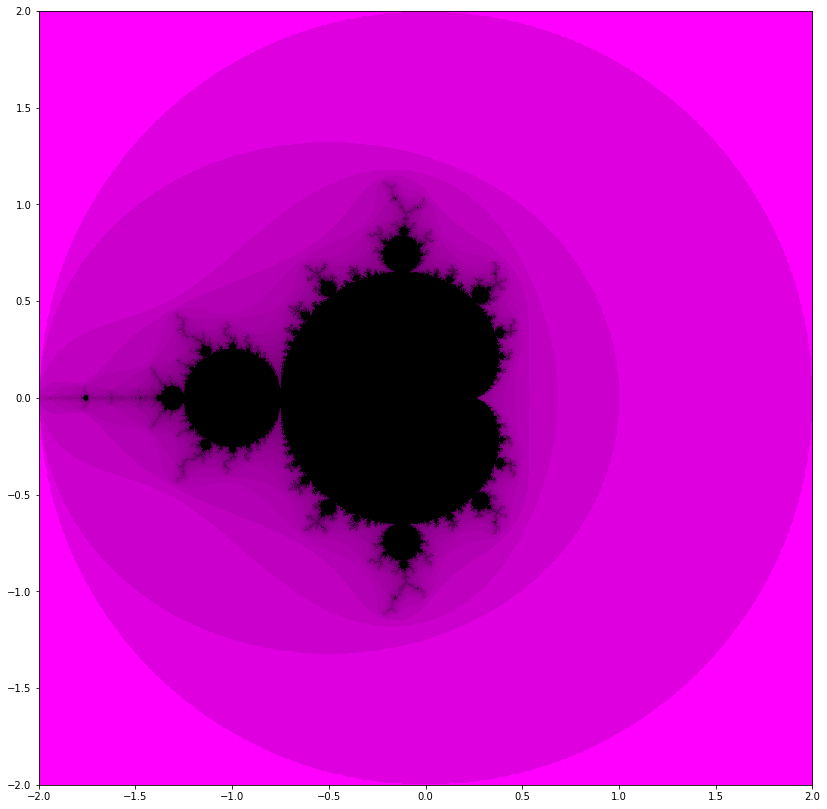

In [10]:
plt.figure(figsize=figsize)
plt.imshow(colour_image, extent=[-2, 2, -2, 2], interpolation="none")
plt.savefig("colour.png")
plt.show()